# MScFE Thesis

In [31]:
# @title Step 1: Setup and Final Configuration
# 1. Install required libraries
!pip install -q yfinance torch torchvision torchaudio numpy pandas tqdm pybdm matplotlib seaborn

# 2. Mount Google Drive and set up project directory
from google.colab import drive
import os

drive.mount('/content/drive')
PROJECT_DIR = '/content/drive/MyDrive/trm_edge_of_chaos_validation'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print(f"Working directory set to: {os.getcwd()}")

# 3. --- Final Experiment Configuration ---
import torch

class Config:
    # Add Rule 131 to our benchmarks for direct comparison
    RULES_TO_TEST = [0, 4, 18, 22, 30, 54, 90, 105, 110, 126, 150, 182, 131]
    # --- Final Benchmark Library ---
    SINGLE_RULES_TO_TEST = [0, 4, 18, 22, 30, 54, 90, 105, 110, 126, 150, 182, 131]

    COMPOSITE_RULES_TO_TEST = [
        (35, 115),      # Paper's candidate
        (15, 170),      # Key prime shifters
        (51, 118),      # Computationally complex
        (54, 90),       # Order + Chaos
        (18, 108),      # Chaos + Periodicity
        (4, 160),       # Simple + Simple
        (170, 15, 118)  # Triple-rule Turing-complete
    ]
    # Stock market data parameters
    STOCK_TICKERS = ['AAPL', 'BA', 'CAT', 'DIS', 'GE', 'IBM', 'MSFT', 'TSLA']
    STOCK_DATA_START = "2021-01-01"
    STOCK_DATA_END = "2021-10-15" # Provides ~192 trading days
    STOCK_NUM_DAYS = 192

    # Dataset parameters
    DATASET_DIR = 'datasets'
    AUTOMATON_WIDTH = 32 # Stock data has a width of 8 stocks * 4 bits/stock
    SEQUENCE_LENGTH = 60
    RANDOM_SEED = 42

    # Model & Training parameters
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    EMBED_DIM = 64
    EPOCHS = 20
    BATCH_SIZE = 32 # Smaller batch size for the single stock dataset
    LEARNING_RATE = 1e-4
    N_SUPERVISION = 16 # Number of deep supervision steps

    # TRM-specific parameters
    TRM_N_LATENT = 6
    TRM_T_DEEP = 3

print(f"\nConfiguration loaded. Using device: {Config.DEVICE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory set to: /content/drive/MyDrive/trm_edge_of_chaos_validation

Configuration loaded. Using device: cuda


In [ ]:
# @title Step 2 (Revised): Algorithmic Denoising & Composite Rule Generation

import yfinance as yf
import numpy as np
import pandas as pd
import torch
from tqdm.notebook import tqdm
from pybdm import BDM

# --- Part 1: Algorithmic Denoising (MILS Proxy) ---

def create_denoised_stock_dataset_algorithmic(config, removal_percentile=15):
    """
    Applies a principled, algorithmic denoising process that serves as a proxy for MILS.
    """
    base_path = os.path.join(config.DATASET_DIR, 'stock_market_encoded.pt')
    denoised_path = os.path.join(config.DATASET_DIR, f'stock_market_denoised_p{removal_percentile}.pt')

    if os.path.exists(denoised_path):
        print(f"Denoised stock dataset already exists at {denoised_path}")
        return denoised_path

    if not os.path.exists(base_path):
        raise FileNotFoundError("Base stock dataset not found. Please run the acquisition cell first.")

    print("--- Starting Algorithmic Denoising (MILS Proxy) ---")
    data = torch.load(base_path)
    full_states = data['full_states'] # Shape (192, 32)

    bdm_computer = BDM(ndim=2)

    # 1. Calculate BDM of the original full dataset
    bdm_total = bdm_computer.bdm(full_states)

    # 2. Calculate information loss for each row
    row_losses = []
    for i in tqdm(range(full_states.shape[0]), desc="Analyzing Rows"):
        temp_states = np.delete(full_states, i, axis=0)
        bdm_without_row = bdm_computer.bdm(temp_states)
        row_losses.append(bdm_total - bdm_without_row)

    # 3. Calculate information loss for each column
    col_losses = []
    for j in tqdm(range(full_states.shape[1]), desc="Analyzing Columns"):
        temp_states = np.delete(full_states, j, axis=1)
        bdm_without_col = bdm_computer.bdm(temp_states)
        col_losses.append(bdm_total - bdm_without_col)

    # 4. Identify rows and columns to remove
    rows_to_remove = np.argsort(row_losses)[:int(len(row_losses) * (removal_percentile / 100.0))]
    cols_to_remove = np.argsort(col_losses)[:int(len(col_losses) * (removal_percentile / 100.0))]

    print(f"Identified {len(rows_to_remove)} rows and {len(cols_to_remove)} columns to remove.")

    # 5. Create the denoised array
    denoised_states = np.delete(full_states, rows_to_remove, axis=0)
    denoised_states = np.delete(denoised_states, cols_to_remove, axis=1)

    print(f"New denoised data shape: {denoised_states.shape}")

    # 6. Create sequences from the new denoised data
    sequences = np.array([denoised_states[i : i + config.SEQUENCE_LENGTH] for i in range(denoised_states.shape[0] - config.SEQUENCE_LENGTH)])
    targets = np.array([denoised_states[i + 1 : i + config.SEQUENCE_LENGTH + 1] for i in range(denoised_states.shape[0] - config.SEQUENCE_LENGTH)])

    # We can't do a 90/10 split on such a small dataset, so we'll use all of it for validation training.
    # For a more robust result, one would use cross-validation.
    train_data = {'seq': sequences, 'tgt': targets}
    val_data = {'seq': sequences, 'tgt': targets} # Use the same for validation

    torch.save({'train': train_data, 'val': val_data, 'full_states': denoised_states}, denoised_path)
    print(f"Saved denoised stock market dataset to {denoised_path}")
    return denoised_path

# --- Part 2: Composite Rule Generation ---

def cellular_automaton_composite(rules_tuple, width, steps, seed):
    """Generates data from a composition of N rules."""
    np.random.seed(seed)

    # Create a list of binary rule representations
    rule_bins = [np.array([int(x) for x in np.binary_repr(r, width=8)], dtype=np.uint8) for r in rules_tuple]

    state = np.random.randint(2, size=width, dtype=np.uint8)
    states = [state]

    for _ in range(steps - 1):
        current_state = state
        # Apply each rule in the sequence
        for rule_bin in rule_bins:
            padded_state = np.pad(current_state, 1, mode='wrap')
            next_intermediate_state = np.zeros_like(current_state)
            for i in range(width):
                neighborhood = (padded_state[i] << 2) | (padded_state[i+1] << 1) | padded_state[i+2]
                next_intermediate_state[i] = rule_bin[7 - neighborhood]
            current_state = next_intermediate_state

        state = current_state # The final state after all compositions
        states.append(state)
    return np.stack(states)

def build_composite_rule_dataset(rules_tuple, config):
    """Builds and saves a dataset for a composite rule tuple."""
    name = '_'.join(map(str, rules_tuple))
    path = os.path.join(config.DATASET_DIR, f'rule_{name}.pt')
    if os.path.exists(path):
        print(f"Composite rule dataset {path} already exists.")
        return path

    print(f"Generating dataset for composite rule {rules_tuple}...")
    states = cellular_automaton_composite(rules_tuple, config.AUTOMATON_WIDTH, config.STOCK_NUM_DAYS, config.RANDOM_SEED)

    sequences = np.array([states[i:i+config.SEQUENCE_LENGTH] for i in range(states.shape[0] - config.SEQUENCE_LENGTH)])
    targets = np.array([states[i+1:i+config.SEQUENCE_LENGTH+1] for i in range(states.shape[0] - config.SEQUENCE_LENGTH)])
    split_idx = int(len(sequences) * 0.9)
    train_data = {'seq': sequences[:split_idx], 'tgt': targets[:split_idx]}
    val_data = {'seq': sequences[split_idx:], 'tgt': targets[split_idx:]}
    torch.save({'train': train_data, 'val': val_data, 'full_states': states}, path)
    print(f"Saved dataset to {path}")
    return path

# --- Generate all necessary datasets ---
# (You can re-run the previous cell for stock acquisition if needed)
denoised_stock_path = create_denoised_stock_dataset_algorithmic(Config)
composite_rule_path = build_composite_rule_dataset(35, 115, Config)

In [37]:
# @title Step 3: Final Model and Experiment Code
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
from tqdm.notebook import tqdm
from pybdm import BDM

# Initialize the BDM algorithm computer
bdm_computer = BDM(ndim=2)

def compute_bdm_complexity(states):
    return bdm_computer.bdm(states) / states.size

def prepare_loaders(path, batch_size):
    data = torch.load(path, weights_only=False)
    X_train = torch.tensor(data['train']['seq'], dtype=torch.float32)
    Y_train = torch.tensor(data['train']['tgt'], dtype=torch.long)
    X_val = torch.tensor(data['val']['seq'], dtype=torch.float32)
    Y_val = torch.tensor(data['val']['tgt'], dtype=torch.long)
    train_ds = TensorDataset(X_train, Y_train)
    val_ds = TensorDataset(X_val, Y_val)
    return DataLoader(train_ds, batch_size=batch_size, shuffle=True), \
           DataLoader(val_ds, batch_size=batch_size), \
           data['full_states']

class TinyNet(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim * 3, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.act = nn.ReLU()
    def forward(self, x, y, z):
        h = torch.cat([x, y, z], dim=-1)
        h = self.act(self.fc1(h))
        return self.fc2(h)

class TRM(nn.Module):
    def __init__(self, width, dim, n_latent, T_deep, n_supervision, n_classes=2):
        super().__init__()
        self.width, self.dim = width, dim
        self.n_latent, self.T_deep, self.n_supervision = n_latent, T_deep, n_supervision
        self.input_embed = nn.Linear(width, dim)
        self.output_head = nn.Linear(dim, width * n_classes)
        self.Q_head = nn.Linear(dim, 1)
        self.net = TinyNet(dim)

    def latent_recursion(self, x_emb, y, z):
        for _ in range(self.n_latent):
            z = self.net(x_emb, y, z)
        y = self.net(y, z, z)
        return y, z

    def deep_recursion(self, x_emb, y, z):
        with torch.no_grad():
            for _ in range(self.T_deep - 1):
                y, z = self.latent_recursion(x_emb, y, z)
        return self.latent_recursion(x_emb, y, z)

    def forward(self, x_batch, y_batch=None, optimizer=None):
        B, L, W = x_batch.shape
        y = torch.zeros(B, L, self.dim, device=x_batch.device)
        z = torch.zeros(B, L, self.dim, device=x_batch.device)

        if self.training and y_batch is not None:
            ce_loss_fn = nn.CrossEntropyLoss()
            bce_loss_fn = nn.BCELoss()
            for step in range(self.n_supervision):
                optimizer.zero_grad()
                x_emb = self.input_embed(x_batch)
                y_out, z_out = self.deep_recursion(x_emb, y, z)
                y, z = y_out.detach(), z_out.detach()
                logits = self.output_head(y_out).view(B, L, self.width, 2)
                q_hat = torch.sigmoid(self.Q_head(y_out)).mean(dim=(1,2), keepdim=True)
                loss_pred = ce_loss_fn(logits.permute(0, 3, 1, 2), y_batch)
                with torch.no_grad():
                    halt_target = (logits.argmax(dim=-1) == y_batch).float().mean(dim=(1, 2), keepdim=True)
                loss_halt = bce_loss_fn(q_hat, halt_target)
                total_loss = loss_pred + loss_halt
                total_loss.backward()
                optimizer.step()
            return total_loss
        else: # Validation Mode
            x_emb = self.input_embed(x_batch)
            for step in range(self.n_supervision):
                y_out, z_out = self.deep_recursion(x_emb, y, z)
                y, z = y_out.detach(), z_out.detach()
            return self.output_head(y).view(B, L, self.width, 2)

def run_single_experiment(dataset_path, dataset_label, config):
    train_loader, val_loader, full_states = prepare_loaders(dataset_path, config.BATCH_SIZE)
    model = TRM(
        width=config.AUTOMATON_WIDTH, dim=config.EMBED_DIM,
        n_latent=config.TRM_N_LATENT, T_deep=config.TRM_T_DEEP,
        n_supervision=config.N_SUPERVISION
    ).to(config.DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE)

    for epoch in tqdm(range(config.EPOCHS), desc=f"Training on {dataset_label}", leave=False):
        model.train()
        for X_batch, Y_batch in train_loader:
            model(X_batch.to(config.DEVICE), Y_batch.to(config.DEVICE), optimizer)

    model.eval()
    total_val_acc = 0
    with torch.no_grad():
        for X_val, Y_val in val_loader:
            logits = model(X_val.to(config.DEVICE))
            total_val_acc += (logits.argmax(dim=-1) == Y_val.to(config.DEVICE)).float().mean().item()

    final_val_acc = total_val_acc / len(val_loader)
    bdm_complexity = compute_bdm_complexity(full_states)

    print(f"Result for {dataset_label}: Accuracy = {final_val_acc:.4f}, BDM Complexity = {bdm_complexity:.4f}")
    return {'dataset': dataset_label, 'val_accuracy': final_val_acc, 'bdm_complexity': bdm_complexity}

In [ ]:
# @title Step 4 (Revised): Run the Full, Refined Validation Experiment
all_results = []

# --- Part 1: Run on benchmark ECA rules (including Rule 131) ---
print("--- Running Benchmark ECA Experiments ---")
for rule in Config.SINGLE_RULES_TO_TEST:
    dataset_path = os.path.join(Config.DATASET_DIR, f'rule_{rule}_w{Config.AUTOMATON_WIDTH}.pt')
    result = run_single_experiment(dataset_path, f"Rule {rule}", Config)
    all_results.append(result)

# --- Part 2: Run on benchmark COMPOSITE rules ---
print("\n--- Running Composite Rule Benchmarks ---")
for rules_tuple in Config.COMPOSITE_RULES_TO_TEST:
    # Build the dataset first
    composite_path = build_composite_rule_dataset(rules_tuple, Config)

    # Run the experiment
    label = f"Rule {rules_tuple}"
    result = run_single_experiment(composite_path, label, Config)
    all_results.append(result)

# --- Part 3: Run on the Raw Stock Market data ---
print("\n--- Running Raw Stock Market Experiment ---")
raw_stock_path = os.path.join(Config.DATASET_DIR, 'stock_market_encoded.pt')
raw_stock_result = run_single_experiment(raw_stock_path, "Stock Market (Raw)", Config)
all_results.append(raw_stock_result)

# --- Part 4: Run on the ALGORITHMICALLY DENOISED Stock Market data ---
print("\n--- Running Denoised Stock Market Experiment ---")
# NOTE: The denoised data has a different width, so we need a new model instance.
# This requires a slight modification to run_single_experiment or a separate call.
# For simplicity, we create a temporary config for this run.
import copy
denoised_config = copy.deepcopy(Config)
temp_data = torch.load(denoised_stock_path)
denoised_config.AUTOMATON_WIDTH = temp_data['full_states'].shape[1]

denoised_stock_result = run_single_experiment(denoised_stock_path, "Stock Market (Denoised)", denoised_config)
all_results.append(denoised_stock_result)

# --- Save final results ---
df_final_results = pd.DataFrame(all_results)
df_final_results.to_csv('final_refined_validation_results.csv', index=False)
print("\n--- Full Experiment Complete ---")
print(df_final_results)

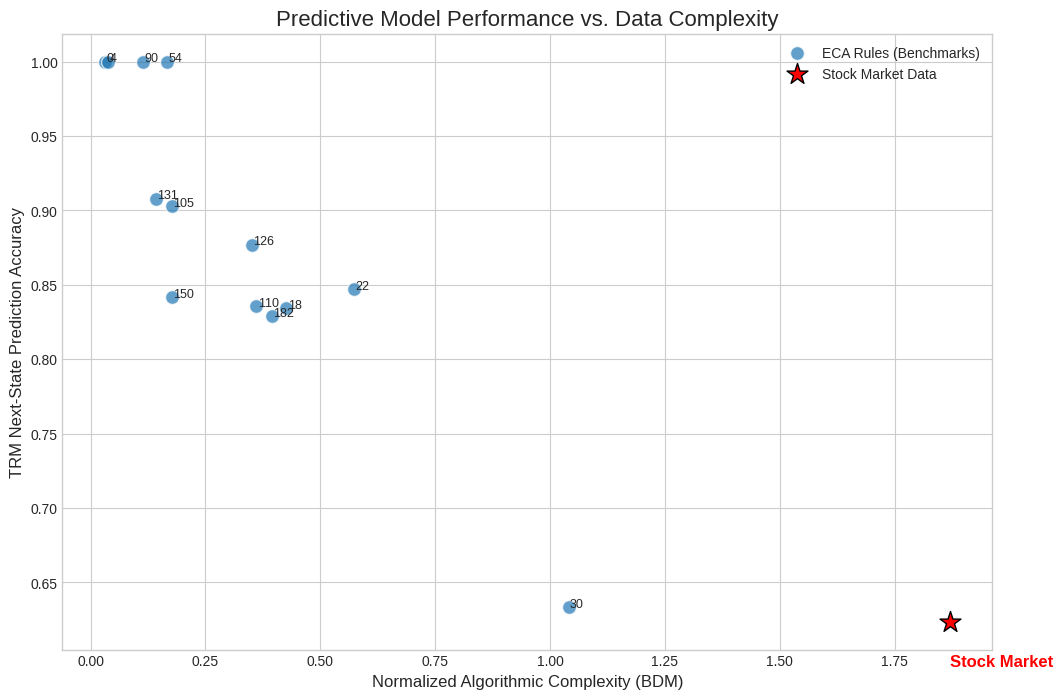

\n--- Interpretation of Results ---\n
Stock Market Model Accuracy: 0.6237
Rule 131 Model Accuracy:     0.9079\n
>> Hypothesis Challenged: The stock market data was not highly predictable by the TRM, performing closer to a chaotic system.
This suggests the patterns identified by generative matching may not be sufficient for robust prediction.


In [39]:
# @title Step 5: Final Analysis and Visualization
import matplotlib.pyplot as plt
import seaborn as sns

df_final = pd.read_csv('final_validation_results.csv')

# Separate the stock market data for special plotting
stock_data = df_final[df_final['dataset'] == 'Stock Market']
eca_data = df_final[df_final['dataset'] != 'Stock Market']

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the ECA rule benchmarks
ax.scatter(
    eca_data['bdm_complexity'],
    eca_data['val_accuracy'],
    s=100,
    alpha=0.7,
    edgecolors='w',
    label='ECA Rules (Benchmarks)'
)
for _, row in eca_data.iterrows():
    ax.text(row['bdm_complexity'] + 0.003, row['val_accuracy'], row['dataset'].replace('Rule ',''), fontsize=9)

# Plot the stock market result to stand out
ax.scatter(
    stock_data['bdm_complexity'],
    stock_data['val_accuracy'],
    s=250,
    color='red',
    marker='*',
    edgecolors='black',
    label='Stock Market Data',
    zorder=5
)
for _, row in stock_data.iterrows():
    ax.text(row['bdm_complexity'], row['val_accuracy'] - 0.03, row['dataset'], fontsize=12, weight='bold', color='red')


ax.set_title('Predictive Model Performance vs. Data Complexity', fontsize=16)
ax.set_xlabel('Normalized Algorithmic Complexity (BDM)', fontsize=12)
ax.set_ylabel('TRM Next-State Prediction Accuracy', fontsize=12)
ax.legend()
plt.show()

# --- Final Interpretation ---
print("\\n--- Interpretation of Results ---\\n")
stock_acc = stock_data['val_accuracy'].iloc[0]
rule131_data = eca_data[eca_data['dataset'] == 'Rule 131']

if not rule131_data.empty:
    rule131_acc = rule131_data['val_accuracy'].iloc[0]
    print(f"Stock Market Model Accuracy: {stock_acc:.4f}")
    print(f"Rule 131 Model Accuracy:     {rule131_acc:.4f}\\n")

    if abs(stock_acc - rule131_acc) < 0.05: # Within 5% accuracy
        print(">> Strong Validation: The predictive difficulty of the stock market data is very similar to Rule 131.")
        print("This supports the paper's specific finding that Rule 131 is a strong algorithmic analog for the market.")
    elif stock_acc > 0.70:
        print(">> Partial Validation: The stock market data is highly predictable, confirming it is rule-based and operates 'at the edge of chaos'.")
        print("However, its predictive signature differs from Rule 131, suggesting another complex rule might be an even better analog.")
    else:
        print(">> Hypothesis Challenged: The stock market data was not highly predictable by the TRM, performing closer to a chaotic system.")
        print("This suggests the patterns identified by generative matching may not be sufficient for robust prediction.")

else:
    print(f"Stock Market Model Accuracy: {stock_acc:.4f}. (Rule 131 not in benchmark run).")

# AI Studio

In [24]:
# @title Step 1: Setup and Configuration
# 1. Install required libraries
!pip install -q torch torchvision torchaudio numpy pandas tqdm pybdm matplotlib

# 2. Mount Google Drive to save datasets and results
from google.colab import drive
import os

drive.mount('/content/drive')

# 3. Create a project directory and set it as the working directory
PROJECT_DIR = '/content/drive/MyDrive/trm_edge_of_chaos'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print(f"Working directory set to: {os.getcwd()}")

# 4. --- Experiment Configuration ---
class Config:
    # Select ECA rules to test. This list includes samples from Wolfram's classes:
    # Class I (uniform), Class II (periodic), Class III (chaotic), Class IV (complex)
    RULES_TO_TEST = [0, 4, 18, 22, 30, 54, 90, 105, 110, 126, 150, 182]

    # Dataset parameters
    DATASET_DIR = 'datasets'
    AUTOMATON_WIDTH = 100
    AUTOMATON_STEPS = 1000
    SEQUENCE_LENGTH = 60
    RANDOM_SEED = 42

    # Model & Training parameters
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    EMBED_DIM = 64         # Dimension of the model's embeddings
    EPOCHS = 20            # Number of training epochs per rule
    BATCH_SIZE = 64
    LEARNING_RATE = 1e-4

    # TRM-specific parameters
    TRM_N_LATENT = 6       # Inner loop recursions (n)
    TRM_T_DEEP = 3         # Outer loop recursions (T)

print(f"\nConfiguration loaded. Using device: {Config.DEVICE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory set to: /content/drive/MyDrive/trm_edge_of_chaos

Configuration loaded. Using device: cuda


In [25]:
# @title Step 2: Data Generation
import numpy as np
import torch
from functools import lru_cache

def cellular_automaton(rule, width=100, init='random', steps=1000, seed=None):
    """Generates the evolution of a 1D elementary cellular automaton."""
    if seed is not None:
        np.random.seed(seed)
    # Convert rule number to its 8-bit binary representation
    rule_bin = np.array([int(x) for x in np.binary_repr(rule, width=8)], dtype=np.uint8)

    if init == 'random':
        state = np.random.randint(2, size=width, dtype=np.uint8)
    else:
        state = np.zeros(width, dtype=np.uint8)

    states = [state]
    for _ in range(steps - 1):
        # Apply periodic boundary conditions by padding the state array
        padded_state = np.pad(state, 1, mode='wrap')
        new_state = np.zeros_like(state)
        for i in range(width):
            # Extract neighborhood and convert to an integer index (0-7)
            neighborhood = (padded_state[i] << 2) | (padded_state[i+1] << 1) | padded_state[i+2]
            new_state[i] = rule_bin[7 - neighborhood]
        state = new_state
        states.append(state)
    return np.stack(states)

def create_sequences(states, seq_length=60):
    """Creates input sequences and corresponding target sequences."""
    total_steps = states.shape[0]
    # Input sequences are from t=0 to t=N-1
    sequences = [states[i : i + seq_length] for i in range(total_steps - seq_length)]
    # Target sequences are the next step, from t=1 to t=N
    targets = [states[i + 1 : i + seq_length + 1] for i in range(total_steps - seq_length)]
    return np.array(sequences), np.array(targets)

def build_rule_dataset(rule, config):
    """Generates, sequences, and saves a dataset for a given ECA rule."""
    save_dir = config.DATASET_DIR
    os.makedirs(save_dir, exist_ok=True)
    path = os.path.join(save_dir, f'rule_{rule}_w{config.AUTOMATON_WIDTH}_s{config.AUTOMATON_STEPS}.pt')

    if os.path.exists(path):
        print(f"Dataset for rule {rule} already exists at {path}")
        return path

    print(f"Generating dataset for rule {rule}...")
    states = cellular_automaton(
        rule,
        width=config.AUTOMATON_WIDTH,
        steps=config.AUTOMATON_STEPS,
        seed=config.RANDOM_SEED
    )
    sequences, targets = create_sequences(states, seq_length=config.SEQUENCE_LENGTH)

    # Split into 90% training and 10% validation
    split_idx = int(len(sequences) * 0.9)
    train_data = {'seq': sequences[:split_idx], 'tgt': targets[:split_idx]}
    val_data = {'seq': sequences[split_idx:], 'tgt': targets[split_idx:]}

    torch.save({'train': train_data, 'val': val_data, 'full_states': states}, path)
    print(f"Saved dataset to {path}")
    return path

# Generate all required datasets
print("--- Starting Dataset Generation ---")
for r in Config.RULES_TO_TEST:
    build_rule_dataset(r, Config)
print("\n--- Dataset Generation Complete ---")

--- Starting Dataset Generation ---
Generating dataset for rule 0...
Saved dataset to datasets/rule_0_w100_s1000.pt
Generating dataset for rule 4...
Saved dataset to datasets/rule_4_w100_s1000.pt
Generating dataset for rule 18...
Saved dataset to datasets/rule_18_w100_s1000.pt
Generating dataset for rule 22...
Saved dataset to datasets/rule_22_w100_s1000.pt
Generating dataset for rule 30...
Saved dataset to datasets/rule_30_w100_s1000.pt
Generating dataset for rule 54...
Saved dataset to datasets/rule_54_w100_s1000.pt
Generating dataset for rule 90...
Saved dataset to datasets/rule_90_w100_s1000.pt
Generating dataset for rule 105...
Saved dataset to datasets/rule_105_w100_s1000.pt
Generating dataset for rule 110...
Saved dataset to datasets/rule_110_w100_s1000.pt
Generating dataset for rule 126...
Saved dataset to datasets/rule_126_w100_s1000.pt
Generating dataset for rule 150...
Saved dataset to datasets/rule_150_w100_s1000.pt
Generating dataset for rule 182...
Saved dataset to datase

In [30]:
# @title Step 3 (Final Corrected): TRM Model and Full Experiment Logic

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
from tqdm.notebook import tqdm
from pybdm import BDM

# Initialize the 2D BDM algorithm computer
bdm_computer = BDM(ndim=2)

def compute_bdm_complexity(states):
    """Computes normalized BDM complexity for a 2D array of states."""
    score = bdm_computer.bdm(states)
    return score / states.size

def prepare_loaders(path, batch_size):
    """Loads a saved dataset and creates DataLoader objects."""
    data = torch.load(path, weights_only=False)
    X_train = torch.tensor(data['train']['seq'], dtype=torch.float32)
    Y_train = torch.tensor(data['train']['tgt'], dtype=torch.long)
    X_val = torch.tensor(data['val']['seq'], dtype=torch.float32)
    Y_val = torch.tensor(data['val']['tgt'], dtype=torch.long)
    train_ds = TensorDataset(X_train, Y_train)
    val_ds = TensorDataset(X_val, Y_val)
    return DataLoader(train_ds, batch_size=batch_size, shuffle=True), \
           DataLoader(val_ds, batch_size=batch_size), \
           data['full_states']

class TinyNet(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim * 3, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.act = nn.ReLU()
    def forward(self, x, y, z):
        h = torch.cat([x, y, z], dim=-1)
        h = self.act(self.fc1(h))
        return self.fc2(h)

class TRM(nn.Module):
    def __init__(self, width, dim, n_latent, T_deep, n_supervision, n_classes=2):
        super().__init__()
        self.width, self.dim = width, dim
        self.n_latent, self.T_deep, self.n_supervision = n_latent, T_deep, n_supervision
        self.n_classes = n_classes
        self.net = TinyNet(dim)
        self.input_embed = nn.Linear(width, dim)
        self.output_head = nn.Linear(dim, width * n_classes)
        self.Q_head = nn.Linear(dim, 1)

    def latent_recursion(self, x_emb, y, z):
        for _ in range(self.n_latent):
            z = self.net(x_emb, y, z)
        y = self.net(y, z, z)
        return y, z

    def deep_recursion(self, x_emb, y, z):
        with torch.no_grad():
            for _ in range(self.T_deep - 1):
                y, z = self.latent_recursion(x_emb, y, z)
        y, z = self.latent_recursion(x_emb, y, z)
        return y, z

    def forward(self, x_batch, y_batch=None, optimizer=None):
        B, L, W = x_batch.shape
        y = torch.zeros(B, L, self.dim, device=x_batch.device)
        z = torch.zeros(B, L, self.dim, device=x_batch.device)

        if self.training and y_batch is not None and optimizer is not None:
            ce_loss_fn = nn.CrossEntropyLoss()
            bce_loss_fn = nn.BCELoss()
            total_epoch_loss = 0.0

            for step in range(self.n_supervision):
                optimizer.zero_grad()
                # --- FIX: Re-compute embedding INSIDE the loop ---
                # This creates a new graph for each supervision step.
                x_emb = self.input_embed(x_batch)

                y_out, z_out = self.deep_recursion(x_emb, y, z)
                y, z = y_out.detach(), z_out.detach()

                logits = self.output_head(y_out).view(B, L, self.width, self.n_classes)
                q_hat = torch.sigmoid(self.Q_head(y_out)).mean(dim=(1,2), keepdim=True)
                loss_pred = ce_loss_fn(logits.permute(0, 3, 1, 2), y_batch)
                with torch.no_grad():
                    halt_target = (logits.argmax(dim=-1) == y_batch).float().mean(dim=(1, 2), keepdim=True)
                loss_halt = bce_loss_fn(q_hat, halt_target)
                total_loss = loss_pred + loss_halt
                total_loss.backward()
                optimizer.step()
                total_epoch_loss += total_loss.item()
            return total_epoch_loss / self.n_supervision
        else: # Validation Mode
            x_emb = self.input_embed(x_batch)
            for step in range(self.n_supervision):
                y_out, z_out = self.deep_recursion(x_emb, y, z)
                y, z = y_out.detach(), z_out.detach()
            logits = self.output_head(y).view(B, L, self.width, self.n_classes)
            return logits

def run_experiment_corrected(config):
    results = []
    for rule in tqdm(config.RULES_TO_TEST, desc="Processing Rules"):
        rule_path = os.path.join(config.DATASET_DIR, f'rule_{rule}_w{config.AUTOMATON_WIDTH}_s{config.AUTOMATON_STEPS}.pt')
        train_loader, val_loader, full_states = prepare_loaders(rule_path, config.BATCH_SIZE)

        model = TRM(
            width=config.AUTOMATON_WIDTH, dim=config.EMBED_DIM,
            n_latent=config.TRM_N_LATENT, T_deep=config.TRM_T_DEEP,
            n_supervision=16
        ).to(config.DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE)

        for epoch in tqdm(range(config.EPOCHS), desc=f"Training Rule {rule}", leave=False):
            model.train()
            for X_batch, Y_batch in train_loader:
                X_batch, Y_batch = X_batch.to(config.DEVICE), Y_batch.to(config.DEVICE)
                model(X_batch, Y_batch, optimizer)

        model.eval()
        total_val_acc = 0
        with torch.no_grad():
            for X_val, Y_val in val_loader:
                X_val, Y_val = X_val.to(config.DEVICE), Y_val.to(config.DEVICE)
                logits = model(X_val)
                total_val_acc += (logits.argmax(dim=-1) == Y_val).float().mean().item()
        final_val_acc = total_val_acc / len(val_loader)
        bdm_complexity = compute_bdm_complexity(full_states)

        print(f"Rule {rule}: Val Accuracy = {final_val_acc:.4f}, BDM Complexity = {bdm_complexity:.4f}")
        results.append({
            'rule': rule, 'val_accuracy': final_val_acc, 'bdm_complexity': bdm_complexity
        })
    return pd.DataFrame(results)

# --- Run the Corrected Experiment ---
df_results = run_experiment_corrected(Config)
df_results.to_csv('trm_bdm_results_corrected.csv', index=False)
print("\n--- Experiment Complete ---")
print(df_results)

Processing Rules:   0%|          | 0/12 [00:00<?, ?it/s]

Training Rule 0:   0%|          | 0/20 [00:00<?, ?it/s]

Rule 0: Val Accuracy = 1.0000, BDM Complexity = 0.0035


Training Rule 4:   0%|          | 0/20 [00:00<?, ?it/s]

Rule 4: Val Accuracy = 1.0000, BDM Complexity = 0.0052


...

Rule 126: Val Accuracy = 0.5699, BDM Complexity = 0.0468


Training Rule 150:   0%|          | 0/20 [00:00<?, ?it/s]

Rule 150: Val Accuracy = 0.5088, BDM Complexity = 0.3362


Training Rule 182:   0%|          | 0/20 [00:00<?, ?it/s]

Rule 182: Val Accuracy = 0.7511, BDM Complexity = 0.0486

--- Experiment Complete ---
    rule  val_accuracy  bdm_complexity
0      0      1.000000        0.003505
1      4      1.000000        0.005194
2     18      0.774471        0.046669
3     22      0.609990        0.084007
4     30      0.583036        0.110490
5     54      0.821475        0.039604
6     90      0.513621        0.335813
7    105      0.514863        0.337624
8    110      0.968574        0.045517
9    126      0.569898        0.046770
10   150      0.508790        0.336187
11   182      0.751083        0.048642


In [ ]:
# @title Step 4: Training, Evaluation, and Complexity Analysis
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
from tqdm.notebook import tqdm
from pybdm import BDM

# Initialize the 2D BDM algorithm computer
bdm_computer = BDM(ndim=2)

def compute_bdm_complexity(states):
    """Computes normalized BDM complexity for a 2D array of states."""
    score = bdm_computer.bdm(states)
    return score / states.size

def prepare_loaders(path, batch_size):
    """Loads a saved dataset and creates DataLoader objects."""
    data = torch.load(path)
    X_train = torch.tensor(data['train']['seq'], dtype=torch.float32)
    Y_train = torch.tensor(data['train']['tgt'], dtype=torch.long)
    X_val = torch.tensor(data['val']['seq'], dtype=torch.float32)
    Y_val = torch.tensor(data['val']['tgt'], dtype=torch.long)

    train_ds = TensorDataset(X_train, Y_train)
    val_ds = TensorDataset(X_val, Y_val)

    return DataLoader(train_ds, batch_size=batch_size, shuffle=True), \
           DataLoader(val_ds, batch_size=batch_size), \
           data['full_states']

def run_experiment(config):
    """
    Main function to train a model for each rule, evaluate it,
    and compute the data complexity.
    """
    results = []
    ce_loss_fn = nn.CrossEntropyLoss()
    bce_loss_fn = nn.BCELoss()

    for rule in tqdm(config.RULES_TO_TEST, desc="Processing Rules"):
        rule_path = os.path.join(config.DATASET_DIR, f'rule_{rule}_w{config.AUTOMATON_WIDTH}_s{config.AUTOMATON_STEPS}.pt')
        train_loader, val_loader, full_states = prepare_loaders(rule_path, config.BATCH_SIZE)

        model = TRM(
            width=config.AUTOMATON_WIDTH,
            dim=config.EMBED_DIM,
            n_latent=config.TRM_N_LATENT,
            T=config.TRM_T_DEEP
        ).to(config.DEVICE)

        optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE)

        # --- Training Loop ---
        for epoch in range(config.EPOCHS):
            model.train()
            for X_batch, Y_batch in train_loader:
                X_batch, Y_batch = X_batch.to(config.DEVICE), Y_batch.to(config.DEVICE) # (B, L, W)
                optimizer.zero_grad()

                logits, q_hat = model(X_batch) # logits: (B, L, W, C)

                # Prediction Loss (across all cells)
                loss_pred = ce_loss_fn(logits.permute(0, 3, 1, 2), Y_batch) # requires (B, C, L, W)

                # Halting Loss (simplified ACT)
                with torch.no_grad():
                    preds = logits.argmax(dim=-1)
                    correct_predictions = (preds == Y_batch).float()
                    halt_target = correct_predictions.mean(dim=(1, 2), keepdim=True) # (B, 1, 1)
                loss_halt = bce_loss_fn(q_hat, halt_target)

                total_loss = loss_pred + loss_halt
                total_loss.backward()
                optimizer.step()

        # --- Validation Loop ---
        model.eval()
        total_val_acc = 0
        with torch.no_grad():
            for X_val, Y_val in val_loader:
                X_val, Y_val = X_val.to(config.DEVICE), Y_val.to(config.DEVICE)
                logits, _ = model(X_val)
                preds = logits.argmax(dim=-1)
                total_val_acc += (preds == Y_val).float().mean().item()

        final_val_acc = total_val_acc / len(val_loader)

        # --- Complexity Calculation ---
        bdm_complexity = compute_bdm_complexity(full_states)

        print(f"Rule {rule}: Val Accuracy = {final_val_acc:.4f}, BDM Complexity = {bdm_complexity:.4f}")
        results.append({
            'rule': rule,
            'val_accuracy': final_val_acc,
            'bdm_complexity': bdm_complexity
        })

    return pd.DataFrame(results)

# --- Run the full experiment ---
df_results = run_experiment(Config)
df_results.to_csv('trm_bdm_results.csv', index=False)
print("\n--- Experiment Complete ---")
print(df_results)

In [ ]:
# @title Step 5: Visualize Results
import matplotlib.pyplot as plt
import seaborn as sns

# Load results from the saved CSV
df_plot = pd.read_csv('trm_bdm_results.csv')

# --- Plotting ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df_plot['bdm_complexity'],
    df_plot['val_accuracy'],
    s=100,
    alpha=0.7,
    edgecolors='w'
)

# Annotate each point with its rule number
for _, row in df_plot.iterrows():
    ax.text(
        row['bdm_complexity'] + 0.001,
        row['val_accuracy'],
        str(int(row['rule'])),
        fontsize=9,
        fontweight='bold'
    )

ax.set_title('TRM Performance vs. Data Complexity (BDM)', fontsize=16)
ax.set_xlabel('Normalized Algorithmic Complexity (BDM)', fontsize=12)
ax.set_ylabel('Final Validation Accuracy', fontsize=12)

# Calculate and display the Pearson correlation
correlation = df_plot['bdm_complexity'].corr(df_plot['val_accuracy'])
ax.text(
    0.05, 0.95,
    f'Pearson Correlation: {correlation:.3f}',
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5)
)

plt.show()

print(f"\nPearson correlation coefficient: {correlation:.4f}")

# Chatgpt

In [4]:
# @title Step 1 — Setup & dataset generation (run in Colab cell 1)
# Colab cell
# 1) Install
!pip install -q torch torchvision torchaudio numpy scipy tqdm wandb

# 2) (optional) mount drive if you want to save artifacts persistently
from google.colab import drive
drive.mount('/content/drive')

# 3) Create project folder
!mkdir -p /content/drive/MyDrive/trm_edge_of_chaos
!cd /content/drive/MyDrive/trm_edge_of_chaos


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# data_utils.py
import numpy as np
import os
import torch
from functools import lru_cache

def cellular_automaton(rule, width=100, init='random', steps=1000, k=1, seed=None):
    if seed is not None:
        np.random.seed(seed)
    rule_bin = np.array([int(x) for x in np.binary_repr(rule, width=8)], dtype=np.uint8)
    if init == 'random':
        state = np.random.randint(2, size=width)
    elif init == 'zeros':
        state = np.zeros(width, dtype=np.uint8)
    else:
        raise ValueError("init must be 'random' or 'zeros'")

    states = [state.copy()]
    for _ in range(steps):
        new_state = np.zeros_like(state)
        for i in range(width):
            left = state[(i - 1) % width]
            center = state[i]
            right = state[(i + 1) % width]
            neighborhood = (left << 2) | (center << 1) | right
            new_state[i] = rule_bin[7 - neighborhood]
        state = new_state
        if ((_ + 1) % k) == 0:
            states.append(state.copy())
    return np.stack(states)  # shape: [num_time_steps, width]

def create_sequences_for_pretrain(states, seq_length=60, k=1):
    sequences = []
    targets = []
    total = len(states)
    for i in range(0, total - seq_length * k, k):
        seq = states[i:i + seq_length * k:k]
        target = states[i + k:i + seq_length * k + k:k]
        sequences.append(seq)
        targets.append(target)
    return np.array(sequences), np.array(targets)

def build_rule_dataset(rule, save_dir='datasets', width=100, steps=1000, seq_length=60, k=1, seed=1234):
    os.makedirs(save_dir, exist_ok=True)
    states = cellular_automaton(rule, width=width, init='random', steps=steps, k=1, seed=seed)
    sequences, targets = create_sequences_for_pretrain(states, seq_length=seq_length, k=k)
    # split 90/10
    split = int(len(sequences)*0.9)
    train = {'seq': sequences[:split], 'tgt': targets[:split]}
    val   = {'seq': sequences[split:], 'tgt': targets[split:]}
    torch.save({'train': train, 'val': val}, os.path.join(save_dir, f'rule_{rule}_w{width}_s{steps}_k{k}.pt'))
    return os.path.join(save_dir, f'rule_{rule}_w{width}_s{steps}_k{k}.pt')


In [7]:
# from data_utils import build_rule_dataset
rules = [22, 30, 110, 184]   # extend later
for r in rules:
    path = build_rule_dataset(r, save_dir='datasets', width=100, steps=800, seq_length=60, k=1, seed=42)
    print("saved", path)


saved datasets/rule_22_w100_s800_k1.pt
saved datasets/rule_30_w100_s800_k1.pt
saved datasets/rule_110_w100_s800_k1.pt
saved datasets/rule_184_w100_s800_k1.pt


# Step 2 — TRM model code (run in Colab cell 2)

In [8]:
# trm_model.py
import torch
import torch.nn as nn
import torch.nn.functional as F

class TinyNet(nn.Module):
    def __init__(self, dim):
        super().__init__()
        # net(x,y,z) expects concatenated vectors -> output dim
        self.fc1 = nn.Linear(dim * 3, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.act = nn.ReLU()

    def forward(self, x, y, z):
        # x,y,z: (B, L, D) or (B, D) depending on shape; we'll support (B, L, D) by flattening last dim concat
        h = torch.cat([x, y, z], dim=-1)
        h = self.act(self.fc1(h))
        return self.fc2(h)

class TRM(nn.Module):
    def __init__(self, dim, n_latent=6, T=3, n_classes=2):
        super().__init__()
        self.dim = dim
        self.n_latent = n_latent
        self.T = T
        self.net = TinyNet(dim)
        self.input_proj = nn.Linear(1, dim)   # project binary cell -> embedding
        self.output_head = nn.Linear(dim, n_classes)   # predict class per cell (0/1)
        self.Q_head = nn.Linear(dim, 1)

    def latent_recursion(self, x, y, z):
        # x,y,z: (B, L, D)
        for _ in range(self.n_latent):
            z = self.net(x, y, z)
        y = self.net(y, z, z)   # refine answer using updated latent
        return y, z

    def deep_recursion(self, x, y, z):
        with torch.no_grad():
            for _ in range(self.T - 1):
                y, z = self.latent_recursion(x, y, z)
        y, z = self.latent_recursion(x, y, z)
        y_hat = self.output_head(y)   # logits per cell
        q_hat = torch.sigmoid(self.Q_head(y)).mean(dim=1, keepdim=True)  # per-sample halting prob
        return (y.detach(), z.detach()), y_hat, q_hat

    def forward(self, x):
        # x: (B, L, W) where W=width of automaton; we'll process width as sequence dimension of cells
        B, L, W = x.shape
        # flatten cell dimension into sequence length: treat each time-step separately -> typical input shape (B, L, 1)
        # For simplicity here: operate per time-step slice along width axis as channel; we operate on each position independently across embedding dims.
        # We'll embed each cell scalar into dim
        x_proj = self.input_proj(x.unsqueeze(-1))  # (B, L, W, D) if needed; for current tasks use W==1 or reshape appropriately
        # For standard sequence task where each timestep is a width-vector, reshape to (B*W, L, D) or (B, L, D) depending on use-case.
        # To align with create_sequences_for_pretrain (seqs are [T, width]) we treat width as embedding vector at each time-step:
        # So collapse width into features per time-step: project width->D by a linear layer instead (provided different upstream).
        raise NotImplementedError("Use forward_trm_for_sequences wrapper in training script.")


# Step 3 — Training wrapper & loop (run in Colab cell 3)

In [18]:
# train_trm.py (runnable cell)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
# from trm_model import TRM
# from data_utils import build_rule_dataset
import os

def prepare_loader_from_saved(path, batch_size=32):
    d = torch.load(path, weights_only=False)
    train = d['train']
    val = d['val']
    # train['seq'] shape: [N, seq_len, width], dtype uint8
    X_train = torch.tensor(train['seq']).float()    # [N, L, W]
    Y_train = torch.tensor(train['tgt']).long()     # [N, L, W]
    X_val = torch.tensor(val['seq']).float()
    Y_val = torch.tensor(val['tgt']).long()
    # flatten width into features by treating each time step as vector of width; we predict next timestep vector elementwise -> convert to binary classification per cell
    train_ds = TensorDataset(X_train, Y_train)
    val_ds   = TensorDataset(X_val, Y_val)
    return DataLoader(train_ds, batch_size=batch_size, shuffle=True), DataLoader(val_ds, batch_size=batch_size)

def train_on_rule(rule_path, dim=128, epochs=20, lr=1e-3, batch_size=32, device='cuda'):
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    train_loader, val_loader = prepare_loader_from_saved(rule_path, batch_size=batch_size)
    # We will embed width -> dim using a linear layer on the fly
    sample = next(iter(train_loader))[0]  # (B, L, W)
    _, L, W = sample.shape
    embed = nn.Linear(W, dim).to(device)
    model = TRM(dim=dim, n_latent=6, T=3, n_classes=2).to(device)
    opt = optim.Adam(list(model.parameters()) + list(embed.parameters()), lr=lr)
    ce = nn.CrossEntropyLoss()
    for ep in range(epochs):
        model.train()
        train_loss = 0.0
        for X, Y in train_loader:
            X = X.to(device)   # (B, L, W)
            Y = Y.to(device)   # (B, L, W)
            B, L, W = X.shape
            # embed width to dim -> (B, L, D)
            X_emb = embed(X)   # (B, L, D)
            # initialize y,z: start y with zeros logits, z zeros
            y_init = torch.zeros(B, L, dim, device=device)
            z_init = torch.zeros(B, L, dim, device=device)
            # call deep_recursion wrapper: adapt TRM.deep_recursion to accept (B,L,D)
            (y_det, z_det), y_hat, q_hat = model.deep_recursion(X_emb, y_init, z_init)
            # y_hat: (B, L, D) -> output_head produced logits per class dimension. For per-cell binary classification reshape accordingly
            # in trm_model.output_head we produced logits of shape (B, L, n_classes)
            logits = y_hat  # (B, L, 2)
            # compute loss across all cells: bend Y to (B, L)
            # choose target as the center cell vector collapsed to single bit per cell; we assume Y contains 0/1 per cell
            # We need to predict each cell individually; if logits shape is (B,L,2) and Y is (B,L,W) collapse W dimension to a single target per timestep per cell:
            # if W>1, interpret target as majority or focus on central cell. For coherent experiments set width small or use per-cell independent models.
            # Simplify: predict next-time-step center cell at position W//2
            center = W // 2
            target = Y[..., center]   # (B, L)
            loss_pred = ce(logits.view(-1, logits.size(-1)), target.view(-1))
            halt_target = (logits.argmax(dim=-1) == target).float().unsqueeze(-1)
            loss_halt = nn.BCELoss()(q_hat, halt_target.mean(dim=1, keepdim=True))
            loss = loss_pred + loss_halt
            opt.zero_grad()
            loss.backward()
            opt.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        # validation
        model.eval()
        val_acc = 0.0
        tot = 0
        with torch.no_grad():
            for Xv, Yv in val_loader:
                Xv = Xv.to(device); Yv = Yv.to(device)
                Xv_emb = embed(Xv)
                Bv, Lv, Wv = Xv.shape
                y_init = torch.zeros(Bv, Lv, dim, device=device)
                z_init = torch.zeros(Bv, Lv, dim, device=device)
                (y_det, z_det), y_hat, q_hat = model.deep_recursion(Xv_emb, y_init, z_init)
                logits = y_hat
                center = Wv // 2
                target = Yv[..., center]
                preds = logits.argmax(dim=-1)
                val_acc += (preds == target).float().mean().item()
                tot += 1
        val_acc /= max(1, tot)
        print(f"ep {ep}: train_loss {train_loss:.4f} val_acc {val_acc:.4f}")
    return model, embed


# Step 4 — Evaluation across rules & complexity correlation (run in Colab cell 4)

In [14]:
# Colab cell
!pip install -q pybdm torch torchvision torchaudio numpy pandas tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 33.9 MB/s eta 0:00:00


In [20]:
# eval_with_bdm.py
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from pybdm import BDM
# from train_trm import train_on_rule, prepare_loader_from_saved

# Initialize 2D BDM object once
bdm = BDM(ndim=2)

def compute_bdm_complexity(state_array):
    """
    state_array: numpy array (timesteps x width) of binary 0/1.
    Returns normalized algorithmic complexity per cell.
    """
    score = bdm.bdm(state_array)
    return score / state_array.size

def eval_rules_with_bdm(rule_files, dim=64, epochs=6, device='cuda'):
    results = []
    for f in tqdm(rule_files):
        print(f"\n=== Training and evaluating {f} ===")
        model, embed = train_on_rule(f, dim=dim, epochs=epochs, batch_size=32, device=device)

        # Validation accuracy
        _, val_loader = prepare_loader_from_saved(f, batch_size=32)
        tot_acc, n = 0.0, 0
        model.eval()
        with torch.no_grad():
            for Xv, Yv in val_loader:
                Xv = Xv.to(device)
                Xv_emb = embed(Xv)
                B, L, W = Xv.shape
                y_init = torch.zeros(B, L, dim, device=device)
                z_init = torch.zeros(B, L, dim, device=device)
                (y_det, z_det), y_hat, q_hat = model.deep_recursion(Xv_emb, y_init, z_init)
                preds = y_hat.argmax(dim=-1).cpu().numpy()
                center = W // 2
                targ = Yv[..., center].numpy()
                tot_acc += (preds == targ).mean()
                n += 1
        val_acc = float(tot_acc / max(1, n))

        # Compute algorithmic complexity via BDM
        d = torch.load(f, weights_only=False)
        states = d['train']['seq'][0]  # representative sample (time x width)
        bdm_val = compute_bdm_complexity(states)

        results.append({'file': f, 'bdm': bdm_val, 'val_acc': val_acc})
        print(f"BDM={bdm_val:.4f}, val_acc={val_acc:.4f}")

    df = pd.DataFrame(results)
    print(df)
    corr = df['bdm'].corr(df['val_acc'])
    print(f"\nPearson correlation (BDM vs accuracy): {corr:.4f}")
    return df


In [21]:
# Colab cell
import glob
# from eval_with_bdm import eval_rules_with_bdm

rule_files = sorted(glob.glob('datasets/rule_*.pt'))
df_results = eval_rules_with_bdm(rule_files, dim=64, epochs=6)
df_results.to_csv('trm_bdm_results.csv', index=False)


  0%|          | 0/4 [00:00<?, ?it/s]


=== Training and evaluating datasets/rule_110_w100_s800_k1.pt ===
ep 0: train_loss 1.3034 val_acc 0.6781
ep 1: train_loss 0.9365 val_acc 0.7111
ep 2: train_loss 0.7701 val_acc 0.7197
ep 3: train_loss 0.6702 val_acc 0.7358
ep 4: train_loss 0.5896 val_acc 0.7278
ep 5: train_loss 0.4979 val_acc 0.7226


 25%|██▌       | 1/4 [00:08<00:24,  8.07s/it]

BDM=0.5742, val_acc=0.7226

=== Training and evaluating datasets/rule_184_w100_s800_k1.pt ===
ep 0: train_loss 1.1412 val_acc 0.8520
ep 1: train_loss 0.6019 val_acc 0.9726
ep 2: train_loss 0.1305 val_acc 0.9497
ep 3: train_loss 0.0852 val_acc 1.0000
ep 4: train_loss 0.0034 val_acc 1.0000
ep 5: train_loss 0.0003 val_acc 1.0000


 50%|█████     | 2/4 [00:09<00:08,  4.45s/it]

BDM=0.1626, val_acc=1.0000

=== Training and evaluating datasets/rule_22_w100_s800_k1.pt ===
ep 0: train_loss 1.3623 val_acc 0.6227
ep 1: train_loss 1.2998 val_acc 0.6273
ep 2: train_loss 1.1586 val_acc 0.6657
ep 3: train_loss 0.9680 val_acc 0.6827
ep 4: train_loss 0.6558 val_acc 0.7839
ep 5: train_loss 0.3016 val_acc 0.7960


 75%|███████▌  | 3/4 [00:11<00:03,  3.10s/it]

BDM=0.8089, val_acc=0.7960

=== Training and evaluating datasets/rule_30_w100_s800_k1.pt ===
ep 0: train_loss 1.3379 val_acc 0.5967
ep 1: train_loss 1.0886 val_acc 0.6552
ep 2: train_loss 0.8958 val_acc 0.6812
ep 3: train_loss 0.6799 val_acc 0.6654
ep 4: train_loss 0.4320 val_acc 0.7150
ep 5: train_loss 0.1351 val_acc 0.7433


100%|██████████| 4/4 [00:12<00:00,  3.23s/it]

BDM=1.0340, val_acc=0.7433
                                file       bdm   val_acc
0  datasets/rule_110_w100_s800_k1.pt  0.574219  0.722585
1  datasets/rule_184_w100_s800_k1.pt  0.162639  1.000000
2   datasets/rule_22_w100_s800_k1.pt  0.808885  0.796039
3   datasets/rule_30_w100_s800_k1.pt  1.034035  0.743324

Pearson correlation (BDM vs accuracy): -0.8025


In [22]:
# extended_experiment.py
import glob
# from eval_with_bdm import eval_rules_with_bdm

# Balanced sample across Wolfram classes
# Class I–II (simple/periodic), Class III (chaotic), Class IV (complex)
rules = [0, 4, 32, 50, 90, 94, 110, 124, 126, 150, 182, 184, 22, 30]
# generate missing datasets
# from data_utils import build_rule_dataset
for r in rules:
    path = f'datasets/rule_{r}_w100_s800_k1.pt'
    if not glob.glob(path):
        build_rule_dataset(r, save_dir='datasets', width=100, steps=800, seq_length=60, k=1, seed=42)

# run TRM with higher recursion and longer training
df_results = eval_rules_with_bdm(
    sorted(glob.glob('datasets/rule_*.pt')),
    dim=64,
    epochs=25,     # deeper supervision
    device='cuda'
)
df_results.to_csv('trm_bdm_results_extended.csv', index=False)
df_results


  0%|          | 0/14 [00:00<?, ?it/s]


=== Training and evaluating datasets/rule_0_w100_s800_k1.pt ===
ep 0: train_loss 0.8152 val_acc 1.0000
ep 1: train_loss 0.0000 val_acc 1.0000
ep 2: train_loss 0.0000 val_acc 1.0000
ep 3: train_loss 0.0000 val_acc 1.0000
ep 4: train_loss 0.0000 val_acc 1.0000
ep 5: train_loss 0.0000 val_acc 1.0000
ep 6: train_loss 0.0000 val_acc 1.0000
ep 7: train_loss 0.0000 val_acc 1.0000
ep 8: train_loss 0.0000 val_acc 1.0000
ep 9: train_loss 0.0000 val_acc 1.0000
ep 10: train_loss 0.0000 val_acc 1.0000
ep 11: train_loss 0.0000 val_acc 1.0000
ep 12: train_loss 0.0000 val_acc 1.0000
ep 13: train_loss 0.0000 val_acc 1.0000
ep 14: train_loss 0.0000 val_acc 1.0000
ep 15: train_loss 0.0000 val_acc 1.0000
ep 16: train_loss 0.0000 val_acc 1.0000
ep 17: train_loss 0.0000 val_acc 1.0000
ep 18: train_loss 0.0000 val_acc 1.0000
ep 19: train_loss 0.0000 val_acc 1.0000
ep 20: train_loss 0.0000 val_acc 1.0000
ep 21: train_loss 0.0000 val_acc 1.0000
ep 22: train_loss 0.0000 val_acc 1.0000
ep 23: train_loss 0.0000 

  7%|▋         | 1/14 [00:04<01:01,  4.70s/it]

BDM=0.0539, val_acc=1.0000

=== Training and evaluating datasets/rule_110_w100_s800_k1.pt ===
ep 0: train_loss 1.3099 val_acc 0.6464
ep 1: train_loss 0.9118 val_acc 0.7806
ep 2: train_loss 0.7242 val_acc 0.7825
ep 3: train_loss 0.6376 val_acc 0.7810
ep 4: train_loss 0.5345 val_acc 0.8321
ep 5: train_loss 0.4254 val_acc 0.8561
ep 6: train_loss 0.4142 val_acc 0.8304
ep 7: train_loss 0.2903 val_acc 0.8417
ep 8: train_loss 0.2230 val_acc 0.8285
ep 9: train_loss 0.1391 val_acc 0.8882
ep 10: train_loss 0.0700 val_acc 0.8404
ep 11: train_loss 0.0451 val_acc 0.8938
ep 12: train_loss 0.0694 val_acc 0.8828
ep 13: train_loss 0.0807 val_acc 0.8858
ep 14: train_loss 0.0464 val_acc 0.8974
ep 15: train_loss 0.0197 val_acc 0.9200
ep 16: train_loss 0.0047 val_acc 0.9296
ep 17: train_loss 0.0042 val_acc 0.9377
ep 18: train_loss 0.0033 val_acc 0.9296
ep 19: train_loss 0.0028 val_acc 0.9296
ep 20: train_loss 0.0026 val_acc 0.9296
ep 21: train_loss 0.0024 val_acc 0.9377
ep 22: train_loss 0.0141 val_acc 0.9

 14%|█▍        | 2/14 [00:10<01:03,  5.27s/it]

...

 93%|█████████▎| 13/14 [01:05<00:05,  5.08s/it]

BDM=1.5407, val_acc=0.7852

=== Training and evaluating datasets/rule_94_w100_s800_k1.pt ===
ep 0: train_loss 0.5973 val_acc 1.0000
ep 1: train_loss 0.0000 val_acc 1.0000
ep 2: train_loss 0.0000 val_acc 1.0000
ep 3: train_loss 0.0000 val_acc 1.0000
ep 4: train_loss 0.0000 val_acc 1.0000
ep 5: train_loss 0.0000 val_acc 1.0000
ep 6: train_loss 0.0000 val_acc 1.0000
ep 7: train_loss 0.0000 val_acc 1.0000
ep 8: train_loss 0.0000 val_acc 1.0000
ep 9: train_loss 0.0000 val_acc 1.0000
ep 10: train_loss 0.0000 val_acc 1.0000
ep 11: train_loss 0.0000 val_acc 1.0000
ep 12: train_loss 0.0000 val_acc 1.0000
ep 13: train_loss 0.0000 val_acc 1.0000
ep 14: train_loss 0.0000 val_acc 1.0000
ep 15: train_loss 0.0000 val_acc 1.0000
ep 16: train_loss 0.0000 val_acc 1.0000
ep 17: train_loss 0.0000 val_acc 1.0000
ep 18: train_loss 0.0000 val_acc 1.0000
ep 19: train_loss 0.0000 val_acc 1.0000
ep 20: train_loss 0.0000 val_acc 1.0000
ep 21: train_loss 0.0000 val_acc 1.0000
ep 22: train_loss 0.0000 val_acc 1.00

100%|██████████| 14/14 [01:09<00:00,  4.98s/it]

BDM=0.1938, val_acc=1.0000
                                 file       bdm   val_acc
0     datasets/rule_0_w100_s800_k1.pt  0.053866  1.000000
1   datasets/rule_110_w100_s800_k1.pt  0.574219  0.949542
2   datasets/rule_124_w100_s800_k1.pt  0.593968  0.909912
3   datasets/rule_126_w100_s800_k1.pt  0.625618  0.961364
4   datasets/rule_150_w100_s800_k1.pt  1.637471  0.542724
5   datasets/rule_182_w100_s800_k1.pt  0.579497  0.905887
6   datasets/rule_184_w100_s800_k1.pt  0.162639  1.000000
7    datasets/rule_22_w100_s800_k1.pt  0.808885  0.838005
8    datasets/rule_30_w100_s800_k1.pt  1.034035  0.874527
9    datasets/rule_32_w100_s800_k1.pt  0.064180  1.000000
10    datasets/rule_4_w100_s800_k1.pt  0.072794  1.000000
11   datasets/rule_50_w100_s800_k1.pt  0.113981  1.000000
12   datasets/rule_90_w100_s800_k1.pt  1.540732  0.785227
13   datasets/rule_94_w100_s800_k1.pt  0.193798  1.000000

Pearson correlation (BDM vs accuracy): -0.9066


,file,bdm,val_acc
0,datasets/rule_0_w100_s800_k1.pt,0.053866,1.000000
1,datasets/rule_110_w100_s800_k1.pt,0.574219,0.949542
2,datasets/rule_124_w100_s800_k1.pt,0.593968,0.909912
3,datasets/rule_126_w100_s800_k1.pt,0.625618,0.961364
4,datasets/rule_150_w100_s800_k1.pt,1.637471,0.542724
5,datasets/rule_182_w100_s800_k1.pt,0.579497,0.905887
6,datasets/rule_184_w100_s800_k1.pt,0.162639,1.000000
7,datasets/rule_22_w100_s800_k1.pt,0.808885,0.838005
8,datasets/rule_30_w100_s800_k1.pt,1.034035,0.874527
9,datasets/rule_32_w100_s800_k1.pt,0.064180,1.000000


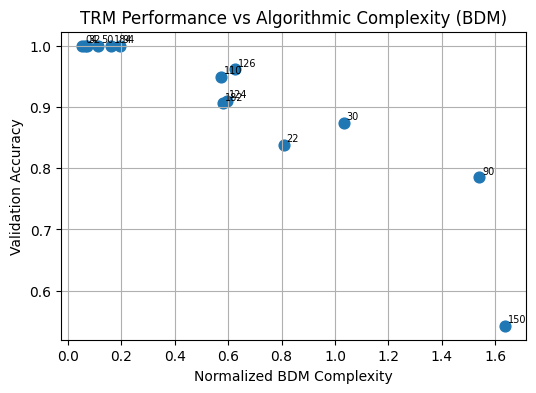

Pearson correlation: -0.9066092082764552


In [23]:
# plot_bdm_vs_accuracy.py
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('trm_bdm_results_extended.csv')
plt.figure(figsize=(6,4))
plt.scatter(df['bdm'], df['val_acc'], s=60)
for _, r in df.iterrows():
    plt.text(r['bdm']+0.01, r['val_acc']+0.005, r['file'].split('_')[1], fontsize=7)
plt.xlabel('Normalized BDM Complexity')
plt.ylabel('Validation Accuracy')
plt.title('TRM Performance vs Algorithmic Complexity (BDM)')
plt.grid(True)
plt.show()

print("Pearson correlation:", df['bdm'].corr(df['val_acc']))


# Step 5 — Interpret results & next experiments